In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

First step is to load the data. After that I will examine each one of the files seperatly to try and spot anomalies.

In [2]:
revenue_df = pd.read_csv('c:/Users/naili/Downloads/revenue.csv - revenue.csv')
spend_df = pd.read_csv('c:/Users/naili/Downloads/spend.csv - spend.csv')

## Revenue DF analysis

In [3]:
revenue_df.head(20)

,date,city,region,revenue_sek,transactions
0,2025-01-01,Boras,Vastra Gotaland,66866.93,99
1,2025-01-01,Eskilstuna,Sodermanland,64413.53,98
2,2025-01-01,Gavle,Gavleborg,69744.08,104
3,2025-01-01,Goteborg,Vastra Gotaland,232221.00,307
4,2025-01-01,Halmstad,Halland,56329.08,85
5,2025-01-01,Helsingborg,Skane,114007.83,154
6,2025-01-01,Jonkoping,Jonkoping,76195.33,107
7,2025-01-01,Karlstad,Varmland,63403.42,91
8,2025-01-01,Kungsbacka,Vastra Gotaland,64784.93,91
9,2025-01-01,Linkoping,Ostergotland,91413.02,129


Next step always checking basic things about the data. This helps to understand how the data look like, if any data cleaning is required. Additionally I add basic descriptive statistics.

In [4]:
print(f'The revenue df looks like {revenue_df.shape}')
print(f'\n Names of lists {revenue_df.columns.tolist()}')
print(f'\n Data types\n{revenue_df.dtypes}')
print(f'\nNull values\n{revenue_df.isnull().sum()}')
print(f'\n Dups {revenue_df.duplicated().sum()}')
print(f'\nBasic Descriptive stats\n{revenue_df.describe()}')

The revenue df looks like (4760, 5)

 Names of lists ['date', 'city', 'region', 'revenue_sek', 'transactions']

 Data types
date             object
city             object
region           object
revenue_sek     float64
transactions      int64
dtype: object

Null values
date            0
city            0
region          0
revenue_sek     0
transactions    0
dtype: int64

 Dups 0

Basic Descriptive stats
         revenue_sek  transactions
count    4760.000000   4760.000000
mean    88495.188882    124.166387
std     48771.017132     61.762630
min         0.000000      0.000000
25%     60194.717500     88.000000
50%     74212.285000    107.000000
75%     97088.915000    136.000000
max    364091.110000    484.000000


Interesting finding that the min of the revenue and transactions are 0. This is either an error in data entry or something happened. Maybe a closed store or just a really bad day. Additionally date is an object instead of datetime. Other than that there seems to be no empty cells, duplicates or any further data cleaning required. Hence, I proceed to some feature engineering.

I convert the date to datetime and then I create a week column. This will help later to understand better what is going and when.

In [5]:
revenue_df['date'] = pd.to_datetime(revenue_df['date'])
revenue_df['week'] = revenue_df['date'].dt.isocalendar().week

According to the case brief, there are treatment and control cities So I create a list of the treatment cities and then using the lambda funcion I match each one of the cities to the group they belong. After that I want to examine the revenue. How much each city made and how does the two groups compare.

In [6]:
#seperate in control and treatment groups to compare their revenue
treatment_cities = ['Goteborg', 'Uppsala', 'Vasteras', 'Orebro', 
                    'Linkoping', 'Karlstad', 'Jonkoping', 
                    'Sundsvall', 'Umea', 'Gavle'] 

revenue_df['group'] = revenue_df['city'].apply(lambda x: 'treatment' if x in treatment_cities else 'control')

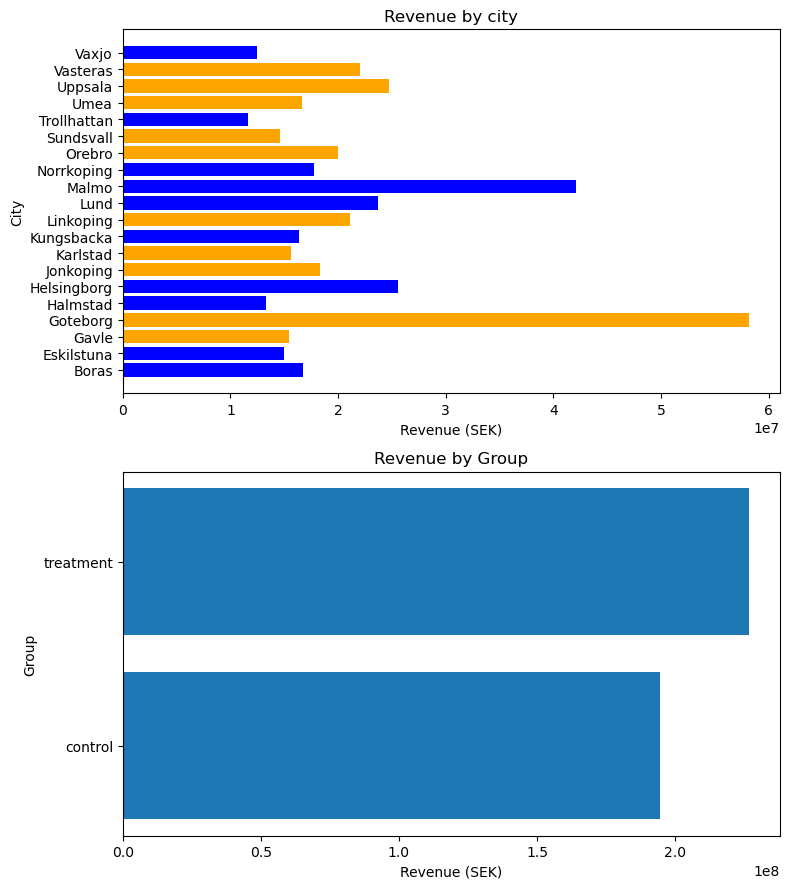

In [7]:
#To examine the revenues I will do a simple groupby and then plot them. 
revenue_by_city = revenue_df.groupby('city').agg({'revenue_sek':'sum'}).reset_index()
revenue_by_group = revenue_df.groupby(['group']).agg({'revenue_sek':'sum'}).reset_index()


fig, ax = plt.subplots(2,1, figsize = (8,9))
#I prefer using this format to do my plots because I feel I have more control over the graphs this way.
color = ['orange' if city in treatment_cities else 'blue' 
          for city in revenue_by_city['city']]
plt1 = ax[0].barh(revenue_by_city['city'],revenue_by_city['revenue_sek'], color = color, )
ax[0].set_title('Revenue by city')
ax[0].set_xlabel('Revenue (SEK)')
ax[0].set_ylabel('City')

plt2 = ax[1].barh(revenue_by_group['group'], revenue_by_group['revenue_sek'] )
ax[1].set_title('Revenue by Group')
ax[1].set_xlabel('Revenue (SEK)')
ax[1].set_ylabel('Group')
plt.tight_layout()
plt.show()

This two graphs shows us the total revenue by city and by group. They do not provide any usefull insights except that Gothenburg and Malmo are the top revenue cities and that treatment group had more revenue than the control. Those two cities has be most revenue and that is completly expected, since they are the largest markets. (In orange the treatment cities) 

Since this does not lead anywhere I will investigate on the 0 min value from the decriptive statistics. First, I find the rows where the reveneu is 0 and then I groupby week and city. Using the size function I get all 3 (city,week, number of days) that the revenue was 0

In [8]:
zeros = revenue_df[revenue_df['revenue_sek']==0]
print(zeros.groupby(['week','city']).size())

week  city   
32    Uppsala    7
33    Uppsala    3
dtype: int64


Hence uppsala has 0 revenue for 10 days between weeks 32-33. This can be due to a not operating store, data collection error.

The next cells have been added here after I did the spend dataframe analysis. The reason I added them afterwards is because I found that the Drive to store campaign happened from week 27 to 35 and I wanted to analyse the revenue those days. 

First I added a period column to the dataset (test -> in Drive to store, Baseline -> only the basic campaigns). A little bit redundant cell but I wanted to have a better idea of it.

In [9]:
revenue_df['period'] = np.where(revenue_df['week'] >= 27, 'test', 'baseline')
revenue_df[(revenue_df['week'].isin([32, 33,34])) & (revenue_df['city'] == 'Uppsala')]

,date,city,region,revenue_sek,transactions,week,group,period
4317,2025-08-04,Uppsala,Uppsala,0.00,0,32,treatment,test
4337,2025-08-05,Uppsala,Uppsala,0.00,0,32,treatment,test
4357,2025-08-06,Uppsala,Uppsala,0.00,0,32,treatment,test
4377,2025-08-07,Uppsala,Uppsala,0.00,0,32,treatment,test
4397,2025-08-08,Uppsala,Uppsala,0.00,0,32,treatment,test
4417,2025-08-09,Uppsala,Uppsala,0.00,0,32,treatment,test
4437,2025-08-10,Uppsala,Uppsala,0.00,0,32,treatment,test
4457,2025-08-11,Uppsala,Uppsala,0.00,0,33,treatment,test
4477,2025-08-12,Uppsala,Uppsala,0.00,0,33,treatment,test
4497,2025-08-13,Uppsala,Uppsala,0.00,0,33,treatment,test


10 days with 0 revenue from 4th August to 13th of August. This could be because the store was closed for summer vacation. 

But how much did this actually impact and cost. How much revenue did the Uppsala lose.

In [10]:
#what uppsala makes in baseline

uppsala_base = revenue_df[
    (revenue_df['city'] == 'Uppsala') & (revenue_df['week'] < 27)
]['revenue_sek'].mean()
print(f'Uppsala average daily revenue before the Drive to store {uppsala_base:,.0f} SEK')
print(f'Hence the estimated cost for 10 days of baseline is {uppsala_base * 10:,.0f} SEK')

Uppsala average daily revenue before the Drive to store 108,775 SEK
Hence the estimated cost for 10 days of baseline is 1,087,750 SEK


In [11]:
#Uppsala's average cost for 10 days of test period Drive to store excluding the 10 days that it was closed. What could it look like

uppsala_test_without_closure = revenue_df[
    (revenue_df['city'] == 'Uppsala') & 
    (revenue_df['week'] >= 27) & 
    (revenue_df['revenue_sek'] != 0)
]['revenue_sek'].mean()

print(f"Uppsala avg daily revenue : {uppsala_test_without_closure:,.0f} SEK")
print(f"Estimated revenue lost (10 days): {uppsala_test_without_closure * 10:,.0f} SEK")


Uppsala avg daily revenue : 107,625 SEK
Estimated revenue lost (10 days): 1,076,248 SEK


So uppsala's baseline revenue is 1.08 million SEK in 10 days, and the cut down sample of test period, drive to store period avg revenue is 1.076.248 million SEK. Approximately this is what costed them.

## Spend DF analysis

In [12]:
spend_df.head(15)

,date,city,region,campaign,adset,spend_sek
0,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Broad Match,940.85
1,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Exact Match,1298.16
2,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Fashion,1852.20
3,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Shoes & Accessories,1200.98
4,2025-01-01,Eskilstuna,Sodermanland,Brand Search,Brand | Broad Match,1062.09
5,2025-01-01,Eskilstuna,Sodermanland,Brand Search,Brand | Exact Match,1406.09
6,2025-01-01,Eskilstuna,Sodermanland,Generic Search,Generic | Fashion,1946.53
7,2025-01-01,Eskilstuna,Sodermanland,Generic Search,Generic | Shoes & Accessories,1419.16
8,2025-01-01,Gavle,Gavleborg,Brand Search,Brand | Broad Match,766.94
9,2025-01-01,Gavle,Gavleborg,Brand Search,Brand | Exact Match,1198.33


Same analysis as for the revenue df

In [13]:
print(f'The spend df looks like {spend_df.shape}')
print(f'\n Names of lists {spend_df.columns.tolist()}')
print(f'\n Data types\n{spend_df.dtypes}')
print(f'\nNull values\n{spend_df.isnull().sum()}')
print(f'\n Dups {spend_df.duplicated().sum()}')
print(f'\nBasic Descriptive stats\n{spend_df.describe()}')

The spend df looks like (21224, 6)

 Names of lists ['date', 'city', 'region', 'campaign', 'adset', 'spend_sek']

 Data types
date          object
city          object
region        object
campaign      object
adset         object
spend_sek    float64
dtype: object

Null values
date         0
city         0
region       0
campaign     0
adset        0
spend_sek    0
dtype: int64

 Dups 0

Basic Descriptive stats
          spend_sek
count  21224.000000
mean    1606.402600
std      893.707326
min      267.590000
25%     1079.725000
50%     1401.525000
75%     1844.007500
max    12467.150000


There is not something surprising here. Again date is an object and no further data cleaning is requeired. I proceed by doing the same things as I did for the revenue df. I convert to datetime, create weeks and group columns

In [14]:
spend_df['date'] = pd.to_datetime(spend_df['date'])
spend_df['week'] = spend_df['date'].dt.isocalendar().week

In [15]:
spend_df['group'] = spend_df['city'].apply(lambda x: 'treatment' if x in treatment_cities else 'control')
spend_df

,date,city,region,campaign,adset,spend_sek,week,group
0,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Broad Match,940.85,1,control
1,2025-01-01,Boras,Vastra Gotaland,Brand Search,Brand | Exact Match,1298.16,1,control
2,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Fashion,1852.20,1,control
3,2025-01-01,Boras,Vastra Gotaland,Generic Search,Generic | Shoes & Accessories,1200.98,1,control
4,2025-01-01,Eskilstuna,Sodermanland,Brand Search,Brand | Broad Match,1062.09,1,control
...,...,...,...,...,...,...,...,...
21219,2025-08-26,Vaxjo,Kronoberg,Brand Search,Brand | Exact Match,993.06,35,control
21220,2025-08-26,Vaxjo,Kronoberg,Generic Search,Generic | Fashion,1377.83,35,control
21221,2025-08-26,Vaxjo,Kronoberg,Generic Search,Generic | Shoes & Accessories,1164.21,35,control
21222,2025-08-26,Vaxjo,Kronoberg,Mid-Season Sale,Sale | Search Promo,400.57,35,control


From here I want to examine the period that I am more interested at. The drive to store campaign

In [16]:
print(spend_df[spend_df['campaign'] == 'Drive to Store'])

            date       city           region        campaign  \
14570 2025-07-02      Gavle        Gavleborg  Drive to Store   
14571 2025-07-02      Gavle        Gavleborg  Drive to Store   
14576 2025-07-02   Goteborg  Vastra Gotaland  Drive to Store   
14577 2025-07-02   Goteborg  Vastra Gotaland  Drive to Store   
14590 2025-07-02  Jonkoping        Jonkoping  Drive to Store   
...          ...        ...              ...             ...   
21197 2025-08-26       Umea     Vasterbotten  Drive to Store   
21204 2025-08-26    Uppsala          Uppsala  Drive to Store   
21205 2025-08-26    Uppsala          Uppsala  Drive to Store   
21212 2025-08-26   Vasteras      Vastmanland  Drive to Store   
21213 2025-08-26   Vasteras      Vastmanland  Drive to Store   

                        adset  spend_sek  week      group  
14570     DtS | Display Local     627.53    27  treatment  
14571  DtS | Social Awareness     745.56    27  treatment  
14576     DtS | Display Local    1921.20    27  tre

Looking at this I want to examine how much sek got spend for each one of the campaigns and if there is an error and drive to store campaign shows up in control group. 

In [17]:
spend_df.groupby(['group','campaign']).agg({
    'spend_sek' : 'sum'
}).reset_index()

,group,campaign,spend_sek
0,control,Brand Search,6196166.02
1,control,Generic Search,8449317.35
2,control,Mid-Season Sale,735943.28
3,treatment,Brand Search,7178480.68
4,treatment,Drive to Store,1341327.78
5,treatment,Generic Search,9788836.52
6,treatment,Mid-Season Sale,404217.16


The Drive to Store only appears in treatment which is good news

Which weeks did the campaing take place?

In [18]:
drive_to_store = spend_df[spend_df['campaign']=='Drive to Store']
print(drive_to_store.groupby('week').agg({
    'spend_sek':'sum'
}))

brand_search = spend_df[spend_df['campaign'] == 'Brand Search']
print(f"\n Brand Search campagin took place \n{brand_search.groupby('week').agg({'spend_sek':'sum'})}")

generic_search = spend_df[spend_df['campaign']== 'Generic Search']
print(f"\n Generic Search Took place \n {generic_search.groupby('week').agg({'spend_sek':'sum'})}")

mid_season_sale = spend_df[spend_df['campaign'] == 'Mid-Season Sale']
print(f"\n Mid Season Sale took place \n {mid_season_sale.groupby('week').agg({'spend_sek':'sum'})}")

      spend_sek
week           
27    105153.15
28    152185.38
29    153956.23
30    164057.63
31    167081.67
32    175787.91
33    181718.77
34    188786.77
35     52600.27

 Brand Search campagin took place 
      spend_sek
week           
1     301148.20
2     401555.48
3     391571.42
4     397489.04
5     402654.03
6     391605.64
7     395612.89
8     390964.86
9     387067.54
10    388047.89
11    392049.05
12    390163.66
13    386401.43
14    394783.53
15    385299.34
16    383806.83
17    382532.65
18    390000.27
19    386054.97
20    392221.78
21    388810.64
22    390039.77
23    389019.07
24    393413.84
25    390464.39
26    390444.22
27    388851.08
28    396527.58
29    399267.86
30    399928.64
31    397973.29
32    401792.97
33    401999.16
34    403978.73
35    111104.96

 Generic Search Took place 
       spend_sek
week           
1     410656.56
2     547575.70
3     533960.97
4     542030.55
5     549073.81
6     534007.75
7     539472.15
8     533133.90
9     

drive to store weeks 27 ->35. Spend on 35 really low, this means its missing days. 

BS ->ALl weeks

GS ->All weeks

MS -> 31-35


In [19]:
print("---Which campaign in what city and how much spend---")
print(f"\nBrand Search\n{brand_search.groupby(['city', 'group'])['spend_sek'].sum().sort_values(ascending=False)}")
print(f"\nMid Season \n{mid_season_sale.groupby(['city', 'group'])['spend_sek'].sum().sort_values(ascending=False)}")
print(f"\nGeneric Search\n{generic_search.groupby(['city', 'group'])['spend_sek'].sum().sort_values(ascending=False)}")
print(f"\nDrive to Store \n{drive_to_store.groupby(['city', 'group'])['spend_sek'].sum().sort_values(ascending=False)}")

---Which campaign in what city and how much spend---

Brand Search
city         group    
Goteborg     treatment    1585668.46
Malmo        control      1187950.68
Helsingborg  control       787705.85
Uppsala      treatment     775667.45
Lund         control       739494.19
Vasteras     treatment     710256.41
Linkoping    treatment     681593.48
Orebro       treatment     658609.45
Jonkoping    treatment     602405.06
Norrkoping   control       598547.38
Boras        control       566879.08
Umea         treatment     562739.99
Karlstad     treatment     557995.56
Gavle        treatment     527320.54
Eskilstuna   control       516636.99
Sundsvall    treatment     516224.28
Kungsbacka   control       474050.44
Halmstad     control       464289.38
Vaxjo        control       435884.44
Trollhattan  control       424727.59
Name: spend_sek, dtype: float64

Mid Season 
city         group    
Malmo        control      477410.49
Goteborg     treatment     93161.60
Helsingborg  control       445

Malmo has an incredible amount of money spend on Mid  compared to the rest. Malmo is also in the control group so this is pushing control groups overall spend up.
 
Additionally, Uppsala has a very high investment in the drive to store, but as we saw before they had 0 revenue in weeks 32-33 which both are inside the drive to store campaign

In [20]:
spend_df.groupby('campaign')['date'].agg(['min', 'max'])

,min,max
campaign,,
Brand Search,2025-01-01,2025-08-26
Drive to Store,2025-07-02,2025-08-26
Generic Search,2025-01-01,2025-08-26
Mid-Season Sale,2025-07-30,2025-08-26


This shows that drive to store starts early july.

which cities each campaign runs on

In [21]:
for campaign in spend_df['campaign'].unique():
    cities = spend_df[spend_df['campaign'] == campaign]['city'].unique()
    print(f"{campaign}: {len(cities)} cities — {sorted(cities)}")

Brand Search: 20 cities — ['Boras', 'Eskilstuna', 'Gavle', 'Goteborg', 'Halmstad', 'Helsingborg', 'Jonkoping', 'Karlstad', 'Kungsbacka', 'Linkoping', 'Lund', 'Malmo', 'Norrkoping', 'Orebro', 'Sundsvall', 'Trollhattan', 'Umea', 'Uppsala', 'Vasteras', 'Vaxjo']
Generic Search: 20 cities — ['Boras', 'Eskilstuna', 'Gavle', 'Goteborg', 'Halmstad', 'Helsingborg', 'Jonkoping', 'Karlstad', 'Kungsbacka', 'Linkoping', 'Lund', 'Malmo', 'Norrkoping', 'Orebro', 'Sundsvall', 'Trollhattan', 'Umea', 'Uppsala', 'Vasteras', 'Vaxjo']
Drive to Store: 10 cities — ['Gavle', 'Goteborg', 'Jonkoping', 'Karlstad', 'Linkoping', 'Orebro', 'Sundsvall', 'Umea', 'Uppsala', 'Vasteras']
Mid-Season Sale: 19 cities — ['Boras', 'Eskilstuna', 'Gavle', 'Goteborg', 'Halmstad', 'Helsingborg', 'Jonkoping', 'Karlstad', 'Linkoping', 'Lund', 'Malmo', 'Norrkoping', 'Orebro', 'Sundsvall', 'Trollhattan', 'Umea', 'Uppsala', 'Vasteras', 'Vaxjo']


Kungsback is not in Mid-Season

Malmo has overspend on Mid-Season 

Next I want to check how much money are spend on the always running campaigns Brand Search and Generic Search

In [22]:
#how much spend is the always on campaigns
spend_df['period'] = np.where(spend_df['week'] >= 27, 'test', 'baseline')
always_on = spend_df[spend_df['campaign'].isin(['Brand Search', 'Generic Search'])]
always_on.groupby(['group', 'period'])['spend_sek'].sum()

group      period  
control    baseline    11018480.59
           test         3627002.78
treatment  baseline    12790953.77
           test         4176363.43
Name: spend_sek, dtype: float64

In [23]:
#average daily spend per city for each group and period
always_on_daily = always_on.groupby(['group', 'period', 'date', 'city'])['spend_sek'].sum().reset_index()
print(always_on_daily.groupby(['group', 'period'])['spend_sek'].mean())

group      period  
control    baseline    6121.378106
           test        6253.453069
treatment  baseline    7106.085428
           test        7200.626603
Name: spend_sek, dtype: float64


It was expected for the test period to be much less spend since the test period is 7.5 weeks and the baseline is 27 weeks.

In [24]:
#spend in uppsala during the closure Aug 4-13 to see how much they wasted
uppsala_wasted = spend_df[
    (spend_df['city'] == 'Uppsala') & 
    (spend_df['date'] >= '2025-08-04') & 
    (spend_df['date'] <= '2025-08-13') &
    (spend_df['campaign'] == 'Drive to Store')
]['spend_sek'].sum()

print(f"Ad spend during Uppsala closure for Drive to Store: {uppsala_wasted:,.0f} SEK")

uppsala_wasted_total = spend_df[
    (spend_df['city'] == 'Uppsala') & 
    (spend_df['date'] >= '2025-08-04') & 
    (spend_df['date'] <= '2025-08-13')]['spend_sek'].sum()

print(f"Ad spend during Uppsala closure: {uppsala_wasted_total} SEK")

Ad spend during Uppsala closure for Drive to Store: 27,470 SEK
Ad spend during Uppsala closure: 122190.65 SEK


So they payed 122191 SEK on a closed store for campaigns! Only 27.470 SEK of those were in the drive to store

How much did Malmo inflate the control group

In [25]:
# Malmö daily revenue: early test  vs during sale
malmo_pre_sale = revenue_df[
    (revenue_df['city'] == 'Malmo') & 
    (revenue_df['date'] >= '2025-06-30') & 
    (revenue_df['date'] < '2025-07-30')
]['revenue_sek'].mean()

malmo_during_sale = revenue_df[
    (revenue_df['city'] == 'Malmo') & 
    (revenue_df['date'] >= '2025-07-30')
]['revenue_sek'].mean()

print(f"Malmö avg daily revenue pre-sale: {malmo_pre_sale:,.0f} SEK")
print(f"Malmö avg daily revenue during sale: {malmo_during_sale:,.0f} SEK")
print(f"Increase: {((malmo_during_sale / malmo_pre_sale) - 1) * 100:.0f}%")

Malmö avg daily revenue pre-sale: 138,263 SEK
Malmö avg daily revenue during sale: 303,442 SEK
Increase: 119%


In [26]:
#malmo vs other cities
mid_season_sale.groupby(['city', 'group'])['spend_sek'].sum().sort_values(ascending=False).head(5)

city         group    
Malmo        control      477410.49
Goteborg     treatment     93161.60
Helsingborg  control       44504.84
Uppsala      treatment     42770.33
Lund         control       42399.66
Name: spend_sek, dtype: float64

In [27]:
#this cell is used later to merge the datasets and does not provide any usefull insights
spend_daily = spend_df.groupby(['date', 'city'])['spend_sek'].sum().reset_index()
spend_daily.rename(columns={'spend_sek': 'total_spend'}, inplace=True)
spend_daily

,date,city,total_spend
0,2025-01-01,Boras,5292.19
1,2025-01-01,Eskilstuna,5833.87
2,2025-01-01,Gavle,4645.18
3,2025-01-01,Goteborg,15462.27
4,2025-01-01,Halmstad,4206.24
...,...,...,...
4755,2025-08-26,Trollhattan,4937.39
4756,2025-08-26,Umea,9142.14
4757,2025-08-26,Uppsala,10044.98
4758,2025-08-26,Vasteras,11177.91


### Key takeaways by now

10 days of zero revenue during the test period. Cost the treatment group ~1.08M SEK in lost revenue. 122k SEK of ad spend was wasted (27k of which was DtS).
Kungsbacka not in Mid Season. small impact but worth mentioning

Malmo extreme investement in mid season received 477k SEK in sale spend, roughly 5× more than any other city. Its daily revenue jumped 119% (138k → 303k). Since Malmö is a control city, this artificially inflates the control group's test-period performance. The second is GB with 93k however GB is a larget market than Malmo and still is 4 times smaller

The treatment group was dragged down by Uppsala while the control up by Malmo

## Merged DF

Merge the revenue and spend data at the city-day level to enable 
combined analysis. Spend is aggregated from campaign-adset level to 
city-day totals first, since in-store revenue cannot be attributed 
to individual campaigns.

In [28]:
df = revenue_df.merge(spend_daily, on=['date', 'city'], how='left')
df

,date,city,region,revenue_sek,transactions,week,group,period,total_spend
0,2025-01-01,Boras,Vastra Gotaland,66866.93,99,1,control,baseline,5292.19
1,2025-01-01,Eskilstuna,Sodermanland,64413.53,98,1,control,baseline,5833.87
2,2025-01-01,Gavle,Gavleborg,69744.08,104,1,treatment,baseline,4645.18
3,2025-01-01,Goteborg,Vastra Gotaland,232221.00,307,1,treatment,baseline,15462.27
4,2025-01-01,Halmstad,Halland,56329.08,85,1,control,baseline,4206.24
...,...,...,...,...,...,...,...,...,...
4755,2025-08-26,Trollhattan,Vastra Gotaland,52751.42,78,35,control,test,4937.39
4756,2025-08-26,Umea,Vasterbotten,76760.45,109,35,treatment,test,9142.14
4757,2025-08-26,Uppsala,Uppsala,118354.60,164,35,treatment,test,10044.98
4758,2025-08-26,Vasteras,Vastmanland,112033.94,162,35,treatment,test,11177.91


In [29]:
#weekly total revenue per city
weekly_city = revenue_df.groupby(['week', 'city', 'group'])['revenue_sek'].sum().reset_index()
#average across cities within each group
weekly_group = weekly_city.groupby(['week', 'group'])['revenue_sek'].mean().reset_index()

In [30]:
weekly_group

,week,group,revenue_sek
0,1,control,443296.672
1,1,treatment,525161.825
2,2,control,605119.248
3,2,treatment,714475.706
4,3,control,581755.710
...,...,...,...
65,33,treatment,737276.927
66,34,control,735729.727
67,34,treatment,787581.617
68,35,control,197574.249


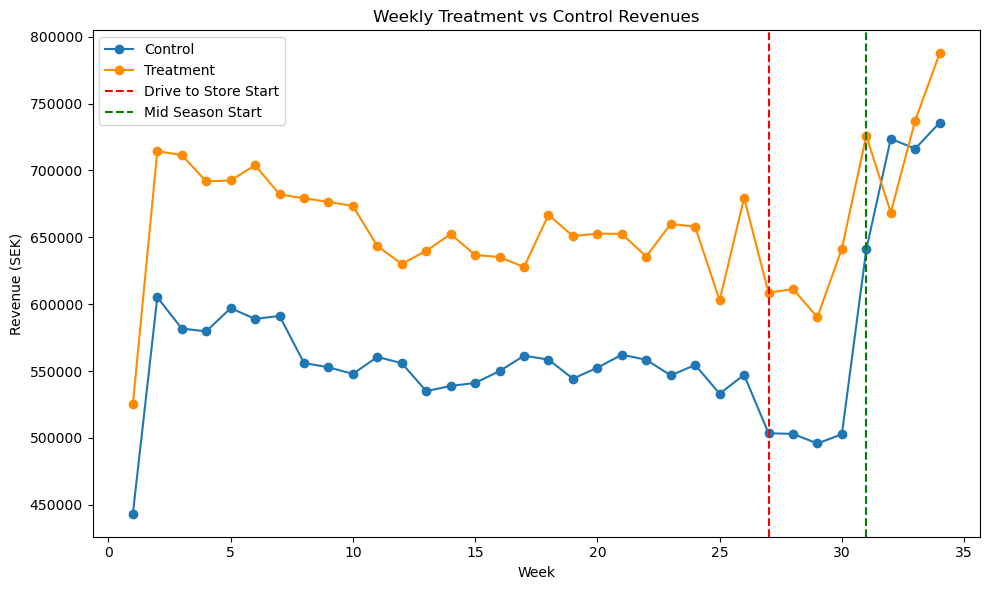

In [31]:
cntrl = weekly_group[
    (weekly_group['group'] == 'control') &
    (weekly_group['week'] <= 34)
]
trt = weekly_group[
    (weekly_group['group'] == 'treatment') &
    (weekly_group['week'] <= 34)
    ]

fig,ax = plt.subplots(figsize=(10,6))

ax.plot(cntrl['week'], cntrl['revenue_sek'], label='Control',marker = 'o')
ax.plot(trt['week'],trt['revenue_sek'], label = 'Treatment', color = 'darkorange', marker = 'o')
ax.set_title('Weekly Treatment vs Control Revenues')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue (SEK)')

plt.axvline(x=27, color='red',linestyle = '--',label = 'Drive to Store Start')
plt.axvline(x=31, color = 'green', linestyle = '--', label = 'Mid Season Start')
plt.tight_layout()
plt.legend()
plt.show()

The parallel trends assumption is the foundation of DiD it requires that treatment and control groups would have followed the same trajectory absent the intervention. The plot confirms this: both groups move in parallel during weeks 1–26, with treatment consistently ~100k higher due to larger cities (primarily Göteborg).

After week 27 (DtS launch), the gap holds steady through week 30. Then at week 31 the Mid-Season Sale launches and control surges upward (Malmö effect), while treatment dips at week 32 (Uppsala closure). This visual confirms why the naive analysis looks negative it's not the campaign failing.

How much did the gap change between the treatment and control group once the Drive to store started

In [32]:
#ALl weeks. 27-34, nothing excluded. 
treatment_before = revenue_df[
    (revenue_df['group'] == 'treatment') & 
    (revenue_df['week'] < 27)
]['revenue_sek'].mean()

treatment_after = revenue_df[
    (revenue_df['group'] == 'treatment') & 
    (revenue_df['week'] >= 27) & 
    (revenue_df['week'] <= 34)
]['revenue_sek'].mean()

control_before = revenue_df[
    (revenue_df['group'] == 'control') & 
    (revenue_df['week'] < 27)
]['revenue_sek'].mean()

control_after = revenue_df[
    (revenue_df['group'] == 'control') & 
    (revenue_df['week'] >= 27) & 
    (revenue_df['week'] <= 34)
]['revenue_sek'].mean()

did = (treatment_after - treatment_before) - (control_after - control_before)

print(f"Treatment before: {treatment_before:,.0f}")
print(f"Treatment after:  {treatment_after:,.0f}")
print(f"Control before:   {control_before:,.0f}")
print(f"Control after:    {control_after:,.0f}")
print(f"\nDiD estimate:     {did:,.0f} SEK per city per day")

Treatment before: 94,862
Treatment after:  95,912
Control before:   80,243
Control after:    86,101

DiD estimate:     -4,808 SEK per city per day


This suggests the DtS campaign *reduced* revenue  but we know this estimate is contaminated by Uppsala's closure (dragging treatment down) and Malmö's sale spend (pushing control up). This is the "surprising negative result" mentioned in the brief. need to clean the data before drawing conclusions.

In [33]:
#Weeks 27-30. Excluding week 32-33 were uppsala was closed and week 31-35 because Mid Season started and Malmo is inflating the control

clean = revenue_df[
    (revenue_df['city'] != 'Uppsala') & 
    (revenue_df['week'] <= 34)
]

treatment_before_clean = clean[
    (clean['group'] == 'treatment') & 
    (clean['week'] < 27)
]['revenue_sek'].mean()

treatment_after_clean = clean[
    (clean['group'] == 'treatment') & 
    (clean['week'] >= 27) & 
    (clean['week'] <= 30)
]['revenue_sek'].mean()

control_before_clean = clean[
    (clean['group'] == 'control') & 
    (clean['week'] < 27)
]['revenue_sek'].mean()

control_after_clean = clean[
    (clean['group'] == 'control') & 
    (clean['week'] >= 27) & 
    (clean['week'] <= 30)
]['revenue_sek'].mean()

did_clean = (treatment_after_clean - treatment_before_clean) - (control_after_clean - control_before_clean)

print(f"Treatment before: {treatment_before_clean:,.0f}")
print(f"Treatment after:  {treatment_after_clean:,.0f}")
print(f"Control before:   {control_before_clean:,.0f}")
print(f"Control after:    {control_after_clean:,.0f}")
print(f"\nClean DiD estimate: {did_clean:,.0f} SEK per city per day")

Treatment before: 93,317
Treatment after:  86,549
Control before:   80,243
Control after:    71,606

Clean DiD estimate: 1,869 SEK per city per day


By excluding Uppsala and restricting to weeks 27–30 (before the Mid-Season Sale), the sign flips from negative to positive. The Drive to Store campaign appears to generate a modest revenue

In [34]:
# Clean DiD is per city per day, for 9 treatment cities (excluding Uppsala)
# Weeks 27-30 = 28 days
incremental_revenue = did_clean * 9 * 28
print(f"Estimated incremental revenue: {incremental_revenue:,.0f} SEK")

# DtS spend during weeks 27-30 only (not the full campaign)
dts_spend_clean = spend_df[
    (spend_df['campaign'] == 'Drive to Store') &
    (spend_df['week'] >= 27) & 
    (spend_df['week'] <= 30) &
    (spend_df['city'] != 'Uppsala')
]['spend_sek'].sum()
print(f"DtS spend (weeks 27-30, excl Uppsala): {dts_spend_clean:,.0f} SEK")

iroas = incremental_revenue / dts_spend_clean
print(f"iROAS: {iroas:.2f}")

Estimated incremental revenue: 471,079 SEK
DtS spend (weeks 27-30, excl Uppsala): 515,114 SEK
iROAS: 0.91


For every 1 SEK spent on DtS, the brand recovered 0.91 SEK in 
incremental in-store revenue. While slightly below breakeven, this 
only captures in-store sales. Online conversions, brand awareness, 
and long-term effects are not measured. Additionally, the campaign 
was still ramping up during this 4-week window (spend increased 
from 105k to 164k per week), suggesting it may not have reached 
full effectiveness.

In [35]:
import statsmodels.formula.api as smf

# Clean data: exclude Uppsala, weeks 1-30 only
reg_data = revenue_df[
    (revenue_df['city'] != 'Uppsala') & 
    (revenue_df['week'] <= 30)
].copy()

reg_data['treat'] = (reg_data['group'] == 'treatment').astype(int)
reg_data['post'] = (reg_data['week'] >= 27).astype(int)
reg_data['treat_post'] = reg_data['treat'] * reg_data['post']

model = smf.ols('revenue_sek ~ treat + post + treat_post', data=reg_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_sek   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     32.71
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           7.10e-21
Time:                        22:42:17   Log-Likelihood:                -47992.
No. Observations:                3952   AIC:                         9.599e+04
Df Residuals:                    3948   BIC:                         9.602e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8.024e+04   1072.133     74.844      0.0

The regression confirms the simple calculation: treat_post = 1,869 SEK. However, the p-value of 0.66 means the result is not statistically significant the confidence interval includes zero (-6,455 to +10,193). With only 9 treatment cities over 4 weeks, the experiment lacks statistical power to detect an effect of this size.

In [36]:
model_fe = smf.ols('revenue_sek ~ C(city) + post + treat_post', data=reg_data).fit()
print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_sek   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     2208.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:42:17   Log-Likelihood:                -43092.
No. Observations:                3952   AIC:                         8.623e+04
Df Residuals:                    3931   BIC:                         8.636e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               7.08

The initial negative result was an artifact of two data issues: 
a 10-day store closure in Uppsala (treatment city, ~1.08M SEK 
lost) and disproportionate Mid-Season Sale spend in Malmo 
(control city, 477k SEK causing a 119% revenue increase).

After correcting for these issues, the DiD estimate turns positive 
(+1,869 SEK/city/day) with an iROAS of 0.91. However, the result 
is not statistically significant (p=0.66), meaning we cannot 
confidently conclude the campaign worked or failed.

**Recommendation**: The campaign shows a directionally positive 
signal but the test was underpowered and contaminated. Before 
deciding to continue or discontinue, the brand should:
1. Run a longer test (12+ weeks) to increase statistical power
2. Ensure no concurrent campaign changes between groups
3. Monitor for operational disruptions (store closures)
4. Consider measuring online conversions alongside in-store revenue

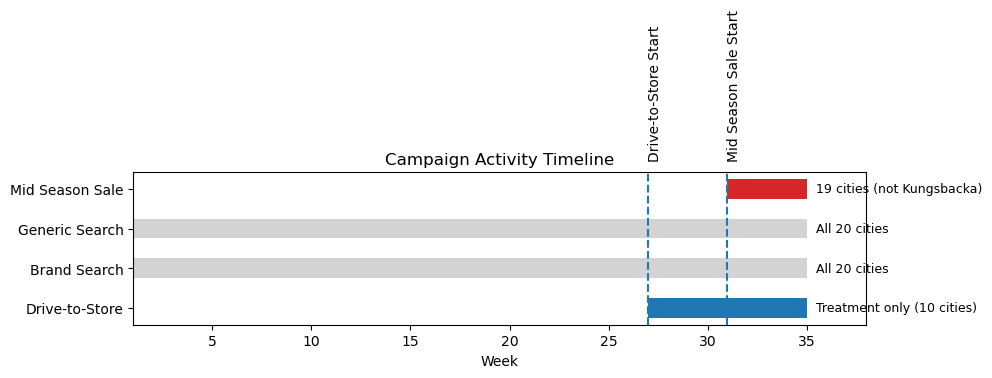

In [37]:
campaigns = [
    ("Drive-to-Store", 27, 35, "Treatment only (10 cities)"),
    ("Brand Search", 1, 35, "All 20 cities"),
    ("Generic Search", 1, 35, "All 20 cities"),
    ("Mid Season Sale", 31, 35, "19 cities (not Kungsbacka)"),
]

colors = ["tab:blue", "lightgray", "lightgray", "tab:red"]

fig, ax = plt.subplots(figsize=(10, 4))

for i, ((name, start, end, label), color) in enumerate(zip(campaigns, colors)):
    ax.barh(i, end - start, left=start, height=0.5, color=color)
    
    # Add label at end of each bar
    ax.text(end + 0.5, i, label, va='center', fontsize=9)

# Y labels
ax.set_yticks(range(len(campaigns)))
ax.set_yticklabels([c[0] for c in campaigns])

# Vertical lines
ax.axvline(x=27, linestyle='--')
ax.axvline(x=31, linestyle='--')

ax.text(27, len(campaigns)-0.3, "Drive-to-Store Start", rotation=90, va='bottom')
ax.text(31, len(campaigns)-0.3, "Mid Season Sale Start", rotation=90, va='bottom')

# X axis
ax.set_xlim(1, 38)  # extend so labels fit
ax.set_xlabel("Week")

# Better title
ax.set_title("Campaign Activity Timeline")

plt.tight_layout()
plt.show()

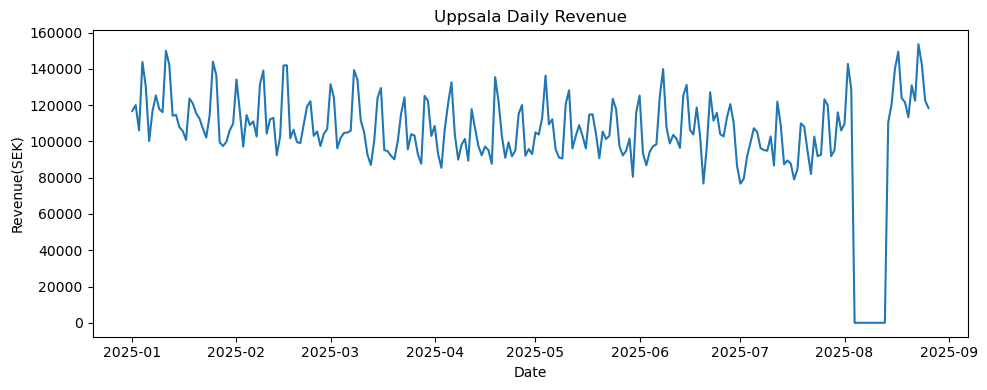

In [38]:
uppsala_rev = revenue_df[revenue_df['city'] == 'Uppsala']
upp_grp = uppsala_rev.groupby(['week','date']).agg({'revenue_sek':'sum'}).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))


ax.plot(upp_grp['date'], upp_grp['revenue_sek'])
ax.set_title('Uppsala Daily Revenue')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue(SEK)')
plt.tight_layout()
plt.show()


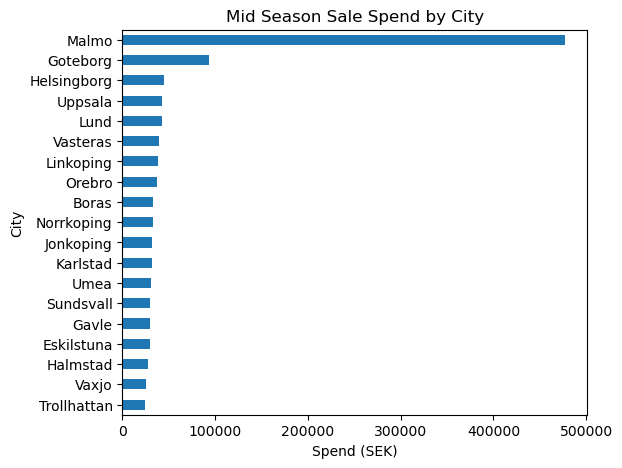

In [39]:
mss_city = mid_season_sale.groupby('city')['spend_sek'].sum().sort_values(ascending=True)

mss_city.plot.barh(figsize=(6,5))

plt.title("Mid Season Sale Spend by City")
plt.xlabel('Spend (SEK)')
plt.ylabel('City')
plt.show()